In [1]:
import xskillscore as xs
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl


In [2]:
ds_S = xr.open_dataset("../scoring/scores/scores_final.nc")
ds_S["S"]=ds_S["S"]*1e2
param0 = pd.read_csv('../proccessing_ensemble/lhs_np15_ns3000_values.txt', sep='\s+')
ds = param0.to_xarray()
param0 = ds.rename({'index': 'sim'})

param=param0.drop_vars(['ytill.cf_negis_centre', 'ytill.cf_negis_south'])
new_order = ['itm.itm_b', 'itm.itm_c', 'marine_shelf.kappa_grz','snap.f_p_ne','ymat.enh_shear','ydyn.beta_q', 'ytill.z0','yneff.delta','ytopo.kt','isostasy.tau','isostasy.He_lith','ytill.cf_negis_north','ctrl.cf_negis_1']
param = param[new_order]

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_245128/1452294326.py:3: SyntaxWarning: invalid escape sequence '\s'
  param0 = pd.read_csv('../proccessing_ensemble/lhs_np15_ns3000_values.txt', sep='\s+')


<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_245128/1994991661.py:3: SyntaxWarning: invalid escape sequence '\m'
  variables_lab =

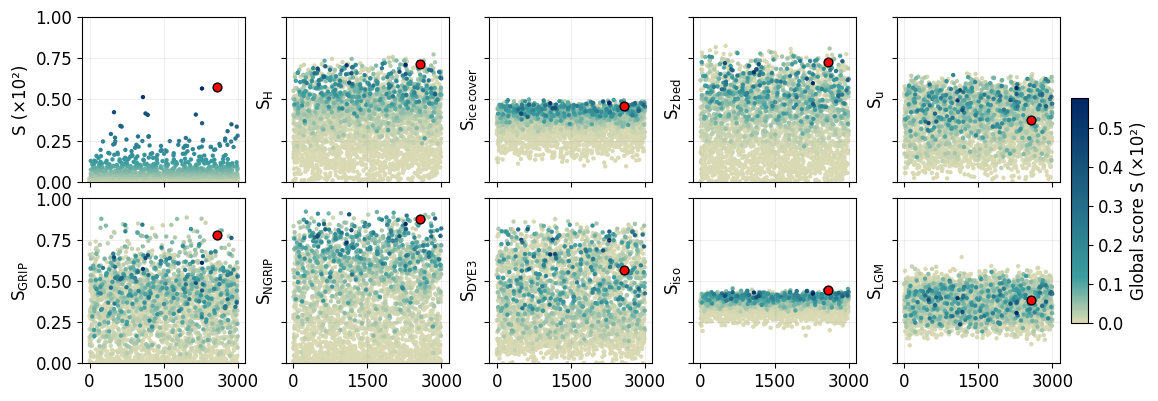

In [3]:

ds_S2 = ds_S.sortby('S')
variables = ["S", "S_H_ice", "S_ice_cover", "S_z_bed", "S_uxy", "S_grip", "S_ngrip","S_dye3", "S_isocr", "S_lgm"]
variables_lab = ["S (×10²)", "S$_{\mathrm{H}}$", "S$_{\mathrm{ice \, cover}}$", "S$_{\mathrm{z \, bed}}$", "S$_{\mathrm{u}}$", "S$_{\mathrm{GRIP}}$", "S$_{\mathrm{NGRIP}}$","S$_{\mathrm{DYE3}}$", "S$_{\mathrm{iso}}$", "S$_{\mathrm{LGM}}$"]

n_vars = len(variables)
n = ds_S.S.argmax().item()
fig, axs = plt.subplots(2, 5, figsize=(11.5,4.5), sharex=True, sharey=True)
axs = axs.flatten()
colors = ["#D9DAB3", "#3C9D9F", "#002665"]
nodes = [0, 0.2, 1.0]
custom_cmap = LinearSegmentedColormap.from_list("custom_warm", list(zip(nodes, colors)))

for i, var in enumerate(variables):
    n_local= ds_S[var].argmax().item()
    ax = axs[i]
    sc=ax.scatter(ds_S2.sim, ds_S2[var], s=10, alpha=1, c=(ds_S2.S), cmap=custom_cmap, edgecolor='none')
    ax.scatter(ds_S.sim.sel(sim=2572), ds_S[var].sel(sim=2572), s=40, alpha=1, color='red',edgecolor='black')
    ax.set_ylabel(f'{variables_lab[i]}')
    ax.grid(True, alpha=0.2)
    ax.set_xticks(np.arange(0, 3001, 1500))
    if i>0:
        ax.set_ylim(0,1)
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.subplots_adjust(left=0.06,right=0.91, hspace=0.1, wspace=0.25)
cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.5])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Global score S (×10²)')
plt.show()
fig.savefig("../figs_final/fig9_score_components.pdf", dpi=300)

In [4]:

scores_names={"S": "S",
    "S_H_ice": "S$_{\mathrm{H}}$",
    "S_ice_cover": "S$_{{\mathrm{ice \, cover}}}$",
    "S_z_bed": "S$_{\mathrm{zbed}}$",
    "S_uxy": "S$_{\mathrm{u}}$",
    "S_grip": "S$_{\mathrm{GRIP}}$",
    "S_ngrip": "S$_{\mathrm{NGRIP}}$",
    "S_dye3": "S$_{\mathrm{DYE3}}$",
    "S_isocr": "S$_{\mathrm{iso}}$",
    "S_lgm": "S$_{\mathrm{LGM}}$"
}

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_245128/769239983.py:2: SyntaxWarning: invalid escape sequence '\m'
  "S_H_ice": "S$

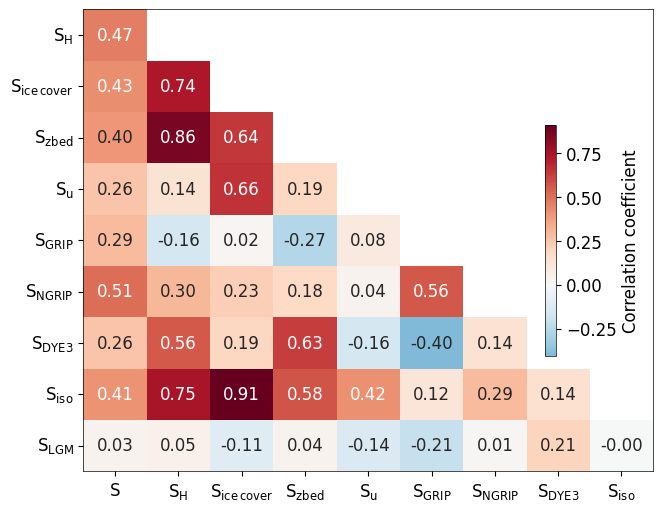

In [5]:
df_all = ds_S[variables].to_dataframe()
corr_matrix = df_all.corr()
corr_recortada = corr_matrix.iloc[1:, :-1]
mask = np.triu(np.ones_like(corr_recortada, dtype=bool), k=1)

plt.figure(figsize=(7, 6))
ax = sns.heatmap(corr_recortada, annot=True, fmt='.2f',cmap='RdBu_r', center=0,mask=mask,
                 cbar_kws={'label': 'Correlation coefficient', 'location': 'right','shrink': 0.5,'pad': -0.2})      

new_xticklabels = [scores_names.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]
new_yticklabels = [scores_names.get(label.get_text(), label.get_text()) for label in ax.get_yticklabels()]

ax.set_xticklabels(new_xticklabels, rotation=0, ha='center')
ax.set_yticklabels(new_yticklabels, rotation=0)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_edgecolor('black')

cbar = ax.collections[0].colorbar
cbar.outline.set_edgecolor('black') 
cbar.outline.set_linewidth(0.5)

plt.savefig("../figs_final/fig10_scores2.pdf", dpi=300)
